In [1]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.linalg import eig


In [33]:
#参数
dela = 0.1875
t = 38*dela
af =40
a = 1
U = 1.9*dela
mz = 7*dela
mu = 8*dela
hc=2#100
h =hc * np.sqrt(mu**2 + dela**2)
#0.5*np.sqrt(h**2 - dela**2)
#L = 11
chaodaojiao = 0
#saimanjiao = np.pi /2
saimanjiao = 0
hz=1*dela 

In [52]:
#参数
dela = 0.1875
t = 38*dela
af =40
a = 1

U = 1.9*dela
mz = 9*dela

mu = 8*dela
hc=1.2#100
h =hc * np.sqrt(mu**2 + dela**2)
#0.5*np.sqrt(h**2 - dela**2)
#L = 11
chaodaojiao = 0
#saimanjiao = np.pi /2
saimanjiao = 0
hz=0*dela

#saimanjiao
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

#左边矩阵信息
HL_block=-(mu-2*t)*s0 + h*np.cos(0)*sx + h*np.sin(0)*sy +  hz*sz
Delta_L=dela * np.exp(1j*chaodaojiao/2) * 1j * sy
H_L_onsite=np.block([
        [ HL_block,        Delta_L        ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])
H_L_right_to_left_hop_block=-1*(t*s0+1j*af*sz/a)
H_L_right_to_left_hop=np.block([
        [ H_L_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_L_right_to_left_hop_block.conj() ]
    ])

#中间矩阵信息
H_center_to_L=np.block([
        [ -t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])
H_center_block=(U-mu+2*t)*s0+mz*sz
H_center=np.block([
        [ H_center_block,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , -H_center_block.conj()  ]
    ])
    
H_center_right_to_left_hop=np.block([
        [ -t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])
H_R_to_center=np.block([
        [ -t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])

#右边矩阵信息
HR_block=-(mu-2*t)*s0 + h*np.cos(saimanjiao)*sx + h*np.sin(saimanjiao)*sy + hz*sz
Delta_R=dela * np.exp(-1j*chaodaojiao/2) * 1j * sy
H_R_onsite=np.block([
        [ HR_block,        Delta_R        ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])
H_R_right_to_left_hop_block=-1*(t*s0+1j*af/a*sz)
H_R_right_to_left_hop=np.block([
        [ H_R_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_R_right_to_left_hop_block.conj() ]
    ])
H_q=H_center
T_12= H_center_right_to_left_hop.conj().T
H_l= H_L_onsite
T_l= H_L_right_to_left_hop
H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T
T_LD=H_center_to_L
T_RD= H_R_to_center
N=10
q=2
print(H_R_onsite)

[[ 12.75      +0.j   1.81400799+0.j   0.        +0.j   0.1875    -0.j]
 [  1.81400799+0.j  12.75      +0.j  -0.1875    +0.j   0.        +0.j]
 [  0.        -0.j  -0.1875    -0.j -12.75      +0.j  -1.81400799+0.j]
 [  0.1875    +0.j   0.        -0.j  -1.81400799+0.j -12.75      +0.j]]


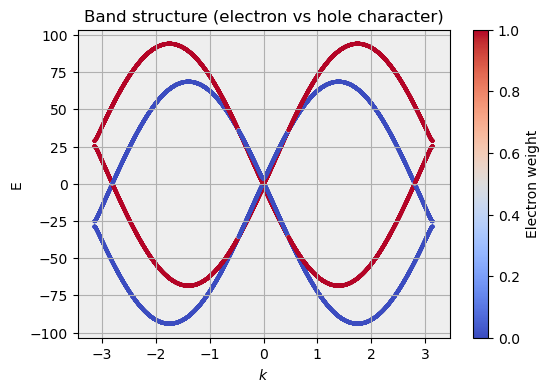

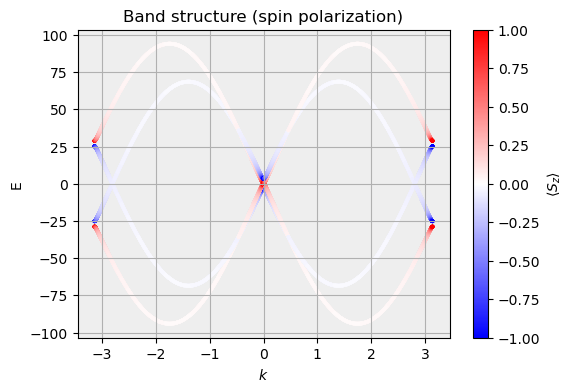

In [25]:
P_e = np.diag([1, 1, 0, 0])
P_h = np.diag([0, 0, 1, 1])
Sz = np.block([
    [sx, np.zeros((2,2))],
    [np.zeros((2,2)), 1*sx]
])

ks = np.linspace(-np.pi, np.pi, 10001)
def Hk(k, H, T):
    return H + T * np.exp(1j*k) + T.conj().T * np.exp(-1j*k)
spin_expect = []
electron_weight = []
energies = []

for k in ks:
    H_k = Hk(k, H_r, T_r)
    evals, evecs = np.linalg.eigh(H_k)

    energies.append(evals)

    # 对每条带计算期望值
    for n in range(len(evals)):
        psi = evecs[:, n]

        w_e = np.real(psi.conj().T @ P_e @ psi)
        s_z = np.real(psi.conj().T @ Sz @ psi)

        electron_weight.append(w_e)
        spin_expect.append(s_z)

energies = np.array(energies)
electron_weight = np.array(electron_weight).reshape(len(ks), -1)
spin_expect = np.array(spin_expect).reshape(len(ks), -1)

from matplotlib.colors import Normalize, TwoSlopeNorm

plt.figure(figsize=(6,4))
ax = plt.gca()
ax.set_facecolor('#eeeeee')   # 关键：浅灰背景

norm_e = Normalize(vmin=0, vmax=1)

for n in range(energies.shape[1]):
    plt.scatter(
        ks,
        energies[:, n],
        c=electron_weight[:, n],
        cmap='coolwarm',
        norm=norm_e,
        s=3
    )

plt.colorbar(label='Electron weight')
plt.xlabel(r'$k$')
plt.ylabel('E')
plt.title('Band structure (electron vs hole character)')
plt.grid(True)
#plt.ylim(-2,2)
plt.show()

plt.figure(figsize=(6,4))
ax = plt.gca()
ax.set_facecolor('#eeeeee')

norm_s = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

for n in range(energies.shape[1]):
    plt.scatter(
        ks,
        energies[:, n],
        c=spin_expect[:, n],
        cmap='bwr',
        norm=norm_s,
        s=3
    )

plt.colorbar(label=r'$\langle S_z \rangle$')
plt.xlabel(r'$k$')
plt.ylabel('E')
plt.title('Band structure (spin polarization)')
plt.grid(True)
#plt.ylim(-dela*3,dela*3)
#plt.xlim(-dela,dela)
plt.show()



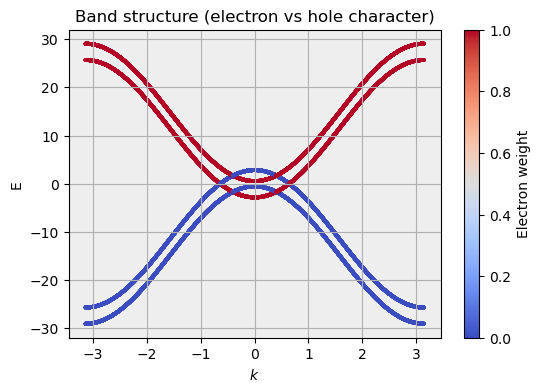

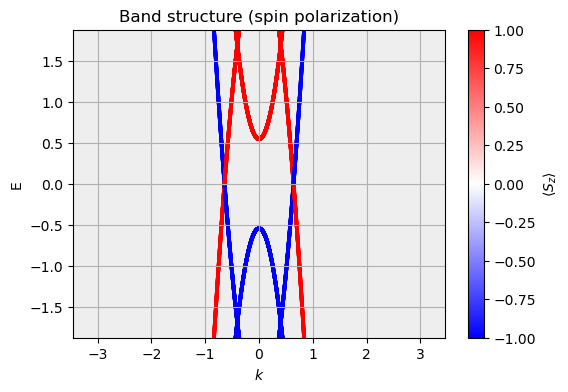

In [54]:
P_e = np.diag([1, 1, 0, 0])
P_h = np.diag([0, 0, 1, 1])
Sz = np.block([
    [sz, np.zeros((2,2))],
    [np.zeros((2,2)), -sz]
])

ks = np.linspace(-np.pi, np.pi, 20001)
def Hk(k, H, T):
    return H + T * np.exp(1j*k) + T.conj().T * np.exp(-1j*k)
spin_expect = []
electron_weight = []
energies = []

for k in ks:
    H_k = Hk(k, H_q, T_12)
    evals, evecs = np.linalg.eigh(H_k)

    energies.append(evals)

    # 对每条带计算期望值
    for n in range(len(evals)):
        psi = evecs[:, n]

        w_e = np.real(psi.conj().T @ P_e @ psi)
        s_z = np.real(psi.conj().T @ Sz @ psi)

        electron_weight.append(w_e)
        spin_expect.append(s_z)

energies = np.array(energies)
electron_weight = np.array(electron_weight).reshape(len(ks), -1)
spin_expect = np.array(spin_expect).reshape(len(ks), -1)

from matplotlib.colors import Normalize, TwoSlopeNorm

plt.figure(figsize=(6,4))
ax = plt.gca()
ax.set_facecolor('#eeeeee')   # 关键：浅灰背景

norm_e = Normalize(vmin=0, vmax=1)

for n in range(energies.shape[1]):
    plt.scatter(
        ks,
        energies[:, n],
        c=electron_weight[:, n],
        cmap='coolwarm',
        norm=norm_e,
        s=3
    )

plt.colorbar(label='Electron weight')
plt.xlabel(r'$k$')
plt.ylabel('E')
plt.title('Band structure (electron vs hole character)')
plt.grid(True)
#plt.ylim(-2,2)
plt.show()

plt.figure(figsize=(6,4))
ax = plt.gca()
ax.set_facecolor('#eeeeee')

norm_s = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

for n in range(energies.shape[1]):
    plt.scatter(
        ks,
        energies[:, n],
        c=spin_expect[:, n],
        cmap='bwr',
        norm=norm_s,
        s=3
    )

plt.colorbar(label=r'$\langle S_z \rangle$')
plt.xlabel(r'$k$')
plt.ylabel('E')
plt.title('Band structure (spin polarization)')
plt.grid(True)
plt.ylim(-10*dela,10*dela)
plt.show()



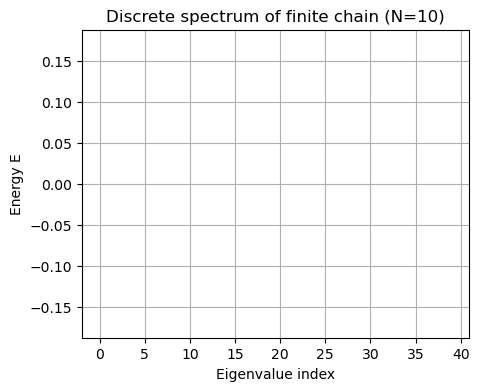

[-26.77902487 -26.77902487 -25.09411284 -25.09411284 -22.43801546
 -22.43801546 -19.02591394 -19.02591394 -15.13423645 -15.13423645
 -11.07826355 -11.07826355  -7.18658606  -7.18658606  -3.77448454
  -3.77448454  -1.11838716  -1.11838716  -0.56652487  -0.56652487
   0.56652487   0.56652487   1.11838716   1.11838716   3.77448454
   3.77448454   7.18658606   7.18658606  11.07826355  11.07826355
  15.13423645  15.13423645  19.02591394  19.02591394  22.43801546
  22.43801546  25.09411284  25.09411284  26.77902487  26.77902487]


In [12]:
import numpy as np

def finite_chain_hamiltonian(H_l, T_l, N):
    d = H_l.shape[0]
    H = np.zeros((N*d, N*d), dtype=complex)

    for i in range(N):
        # onsite
        H[i*d:(i+1)*d, i*d:(i+1)*d] = H_l

        # hopping to right
        if i < N-1:
            H[i*d:(i+1)*d, (i+1)*d:(i+2)*d] = T_l
            H[(i+1)*d:(i+2)*d, i*d:(i+1)*d] = T_l.conj().T

    return H
N_chain = 10
H_finite = finite_chain_hamiltonian(H_q, T_12, N_chain)
Evals = np.linalg.eigvalsh(H_finite)
Evals = np.sort(np.real(Evals))
plt.figure(figsize=(5,4))

plt.plot(
    np.arange(len(Evals)),   # x 轴：能级编号
    Evals,                   # y 轴：能量
    'o'
)

plt.xlabel('Eigenvalue index')
plt.ylabel('Energy E')
plt.title('Discrete spectrum of finite chain (N=10)')
plt.grid(True)
plt.ylim(-1*dela,1*dela)
plt.show()
print(Evals)


In [ ]:
def Gr_DD_0(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, E, eta=3e-6):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(E + 1j*eta)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E + 1j*eta)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    g_ii = [np.zeros((d, d), dtype=complex) for _ in range(N)]

    d_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]#第一个是0
    for i in range(N-1,-1,-1):
        if i==N-1:
            d_R[i]=A_DD[i][i]
        else:
            c_R[i+1]=-1*A_DD[i][i+1] @ np.linalg.inv(d_L[i+1])
            d_R[i]=A_DD[i][i]+c_R[i+1] @ A_DD[i+1][i]

    d_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]#最后一个是0

    for i in range(N):
        if i==0:
            d_L[i]=A_DD[i][i]
        else:
            c_L[i-1]=-1*A_DD[i][i-1] @ np.linalg.inv(d_L[i-1])
            d_L[i]=A_DD[i][i]+ c_L[i-1] @ A_DD[i-1][i]

        g_ii[i]=np.linalg.inv(-A_DD[i][i]+d_L[i]+d_R[i])

    G_DD_r = [[Z.copy() for _ in range(N)] for _ in range(N)]
    for i in range(N):
        for j in range(N):

            if i == j:
                G_DD_r[i][j] = g_ii[i]

            elif i > j:
                prod = np.eye(d, dtype=complex)
                for k in range(i-1, j-1, -1):
                    prod = prod @ c_L[k]
                G_DD_r[i][j] = g_ii[i] @ prod


            else:  
                prod = np.eye(d, dtype=complex)
                for k in range(i+1, j+1):
                    prod = prod @ c_R[k]
                G_DD_r[i][j] = g_ii[i] @ prod


    return G_DD_r , A_DD , Sigma_R , Sigma_L 

In [ ]:
for i in range(3,-1,-1):
    print(i)